# Binary

C:\Users\HP\AppData\Local\Temp\ipykernel_21040\4081414277.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Acc', 'Prec', 'Rec', 'Spec', 'F1'], y=m_vals, ax=axes[6, i], palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_21040\4081414277.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Acc', 'Prec', 'Rec', 'Spec', 'F1'], y=m_vals, ax=axes[6, i], palette='magma')


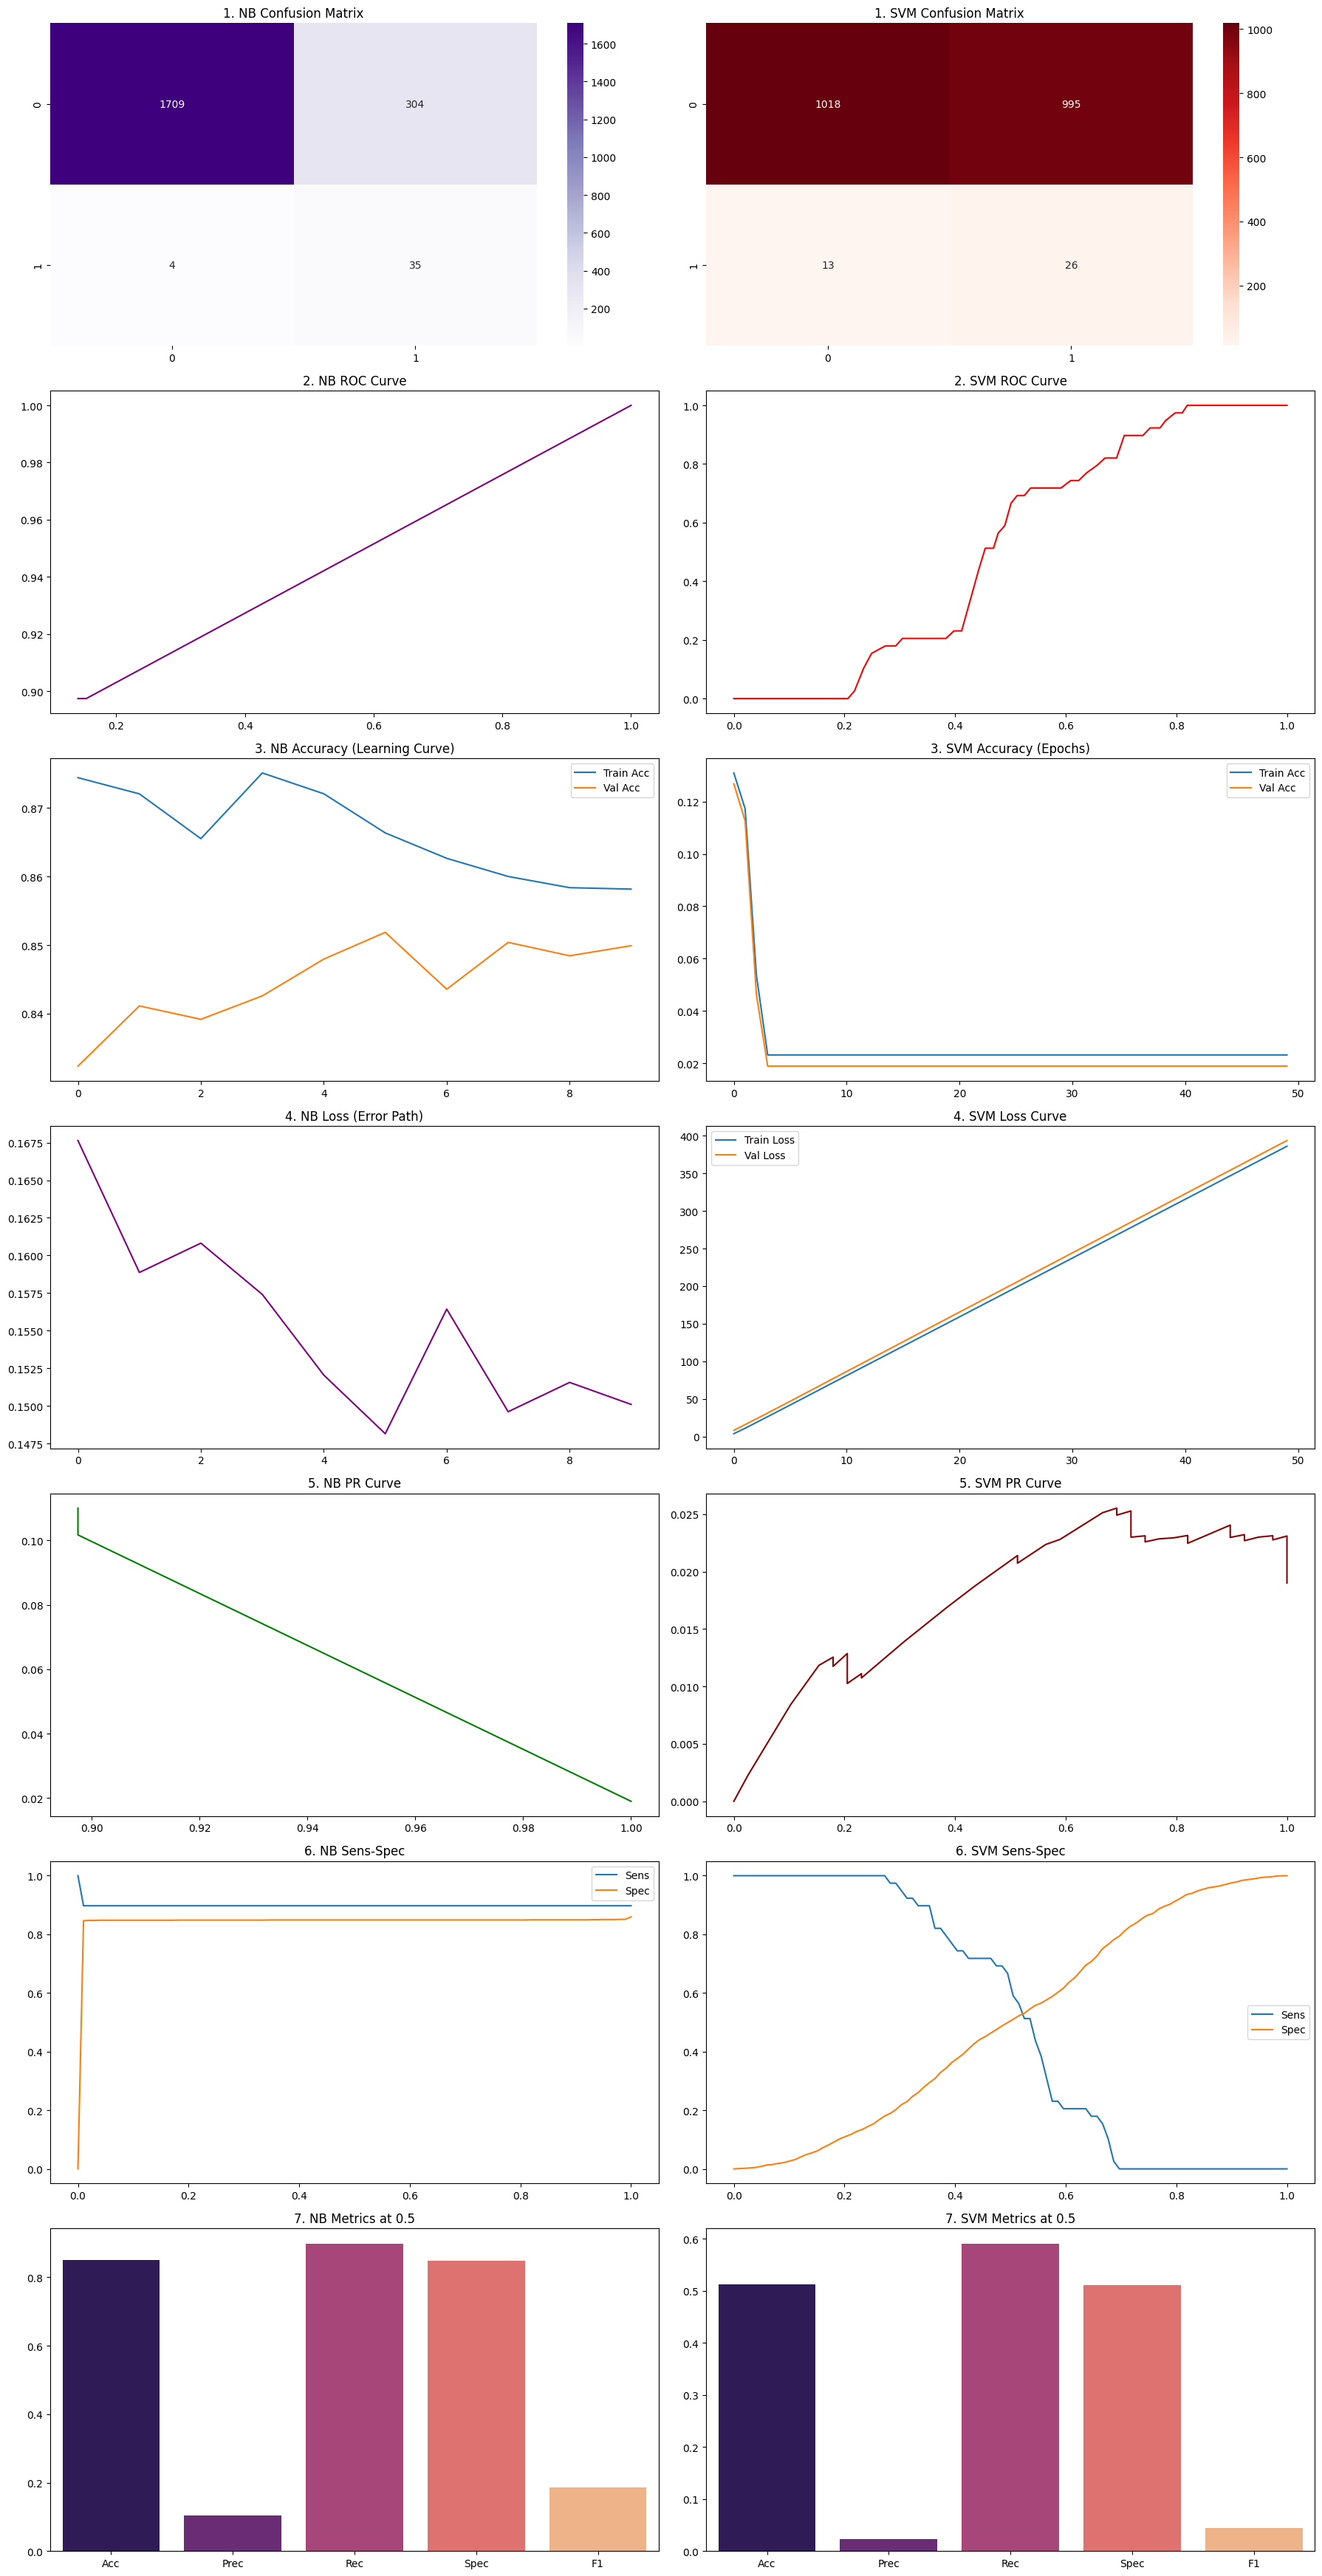


==================== NAIVE BAYES REPORT ====================
Accuracy:    0.8499
Recall:      0.8974
Precision:   0.1032
Specificity: 0.8490
F1 Score:    0.1852

==================== SVM REPORT ====================
Accuracy:    0.5117
Recall:      0.5897
Precision:   0.0228
Specificity: 0.5102
F1 Score:    0.0439


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Data Loading & Cleaning ---
FILE_PATH = 'binary_processed_motor_data_stacked_1000features.csv'

if not os.path.exists(FILE_PATH):
    print(f"❌ Error: '{FILE_PATH}' nahi mili.")
else:
    df = pd.read_csv(FILE_PATH, low_memory=False)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()

    X = df.drop('Label', axis=1).values.astype(float)
    y = df['Label'].values.reshape(-1, 1).astype(float)

    # Manual Standardization
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
    
    # Shuffle and Split
    indices = np.random.permutation(len(X))
    split = int(0.8 * len(X))
    X_train, X_test = X[indices[:split]], X[indices[split:]]
    y_train, y_test = y[indices[:split]], y[indices[split:]]
    y_te_flat = y_test.flatten()

# =====================================================
# 2. MODELS FROM SCRATCH (With Added History Tracking)
# =====================================================

class NaiveBayesScratch:
    def __init__(self):
        self.train_acc_history = []
        self.val_acc_history = []
        self.loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        self.classes = np.unique(y)
        # To create Accuracy/Loss curves for NB, we simulate training on chunks
        for s in np.linspace(0.1, 1.0, 10):
            idx = int(len(X) * s)
            X_sub, y_sub = X[:idx], y[:idx]
            
            self.params = []
            for c in self.classes:
                X_c = X_sub[(y_sub == c).flatten()]
                self.params.append({
                    'mean': np.mean(X_c, axis=0),
                    'var': np.var(X_c, axis=0) + 1e-4,
                    'prior': len(X_c) / len(X_sub)
                })
            
            # History for Question 3
            self.train_acc_history.append(np.mean(self.predict(X_sub) == y_sub.flatten()))
            if X_val is not None:
                val_p = self.predict(X_val)
                self.val_acc_history.append(np.mean(val_p == y_val.flatten()))
                self.loss_history.append(1 - self.val_acc_history[-1])

    def predict(self, X):
        return (self.predict_prob(X) >= 0.5).astype(int)

    def predict_prob(self, X):
        probs = []
        for x in X:
            posteriors = []
            for p in self.params:
                log_prior = np.log(p['prior'])
                log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * p['var']))
                log_likelihood -= 0.5 * np.sum(((x - p['mean'])**2) / p['var'])
                posteriors.append(log_prior + log_likelihood)
            exp_p = np.exp(posteriors - np.max(posteriors))
            probs.append(exp_p[1] / np.sum(exp_p))
        return np.array(probs)



class SVM_Scratch:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=50):
        self.lr, self.lambda_param, self.epochs = lr, lambda_param, epochs
        self.loss_history, self.val_loss_history = [], []
        self.train_acc_history, self.val_acc_history = [], []

    def fit(self, X_tr, y_tr, X_te, y_te):
        y_svm_tr = np.where(y_tr <= 0, -1, 1).flatten()
        y_svm_te = np.where(y_te <= 0, -1, 1).flatten()
        self.w, self.b = np.zeros(X_tr.shape[1]), 0
        
        for epoch in range(self.epochs):
            loss = 0
            for i, x in enumerate(X_tr):
                if y_svm_tr[i] * (np.dot(x, self.w) + self.b) < 1:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y_svm_tr[i] * x)
                    self.b -= self.lr * y_svm_tr[i]
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                loss += max(0, 1 - y_svm_tr[i] * (np.dot(x, self.w) + self.b))
            
            self.loss_history.append(loss / len(y_tr))
            # Tracking Val Loss for Plot 4
            v_loss = np.mean([max(0, 1 - y_svm_te[j] * (np.dot(X_te[j], self.w) + self.b)) for j in range(len(y_te))])
            self.val_loss_history.append(v_loss)
            
            self.train_acc_history.append(np.mean(np.sign(np.dot(X_tr, self.w) + self.b) == y_svm_tr))
            self.val_acc_history.append(np.mean(np.sign(np.dot(X_te, self.w) + self.b) == y_svm_te))

    def predict_score(self, X):
        scores = np.dot(X, self.w) + self.b
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)



# --- Train ---
nb_model = NaiveBayesScratch()
nb_model.fit(X_train, y_train, X_test, y_test)
nb_probs = nb_model.predict_prob(X_test)

svm_model = SVM_Scratch()
svm_model.fit(X_train, y_train, X_test, y_test)
svm_probs = svm_model.predict_score(X_test)

# =====================================================
# 3. METRICS DATA (Function as per your old code)
# =====================================================
def get_detailed_metrics(probs, y_true):
    thresholds = np.linspace(0, 1, 100)
    data = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = np.sum((y_true == 1) & (preds == 1))
        tn = np.sum((y_true == 0) & (preds == 0))
        fp = np.sum((y_true == 0) & (preds == 1))
        fn = np.sum((y_true == 1) & (preds == 0))
        acc = (tp + tn) / len(y_true)
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8) 
        spec = tn / (tn + fp + 1e-8)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
        data.append([t, acc, prec, rec, spec, f1, 1-spec])
    return pd.DataFrame(data, columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'FPR'])

nb_df = get_detailed_metrics(nb_probs, y_te_flat)
svm_df = get_detailed_metrics(svm_probs, y_te_flat)

# =====================================================
# 4. VISUALIZATIONS (14 Plots)
# =====================================================
fig, axes = plt.subplots(7, 2, figsize=(18, 35))

# Row 1: Confusion Matrices
for i, (probs, name, cmap) in enumerate([(nb_probs, 'NB', 'Purples'), (svm_probs, 'SVM', 'Reds')]):
    preds = (probs >= 0.5).astype(int)
    cm = [[np.sum((y_te_flat==0)&(preds==0)), np.sum((y_te_flat==0)&(preds==1))],
          [np.sum((y_te_flat==1)&(preds==0)), np.sum((y_te_flat==1)&(preds==1))]]
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[0, i])
    axes[0, i].set_title(f"1. {name} Confusion Matrix")

# Row 2: ROC Curves
axes[1, 0].plot(nb_df['FPR'], nb_df['Recall'], color='purple'); axes[1, 0].set_title("2. NB ROC Curve")
axes[1, 1].plot(svm_df['FPR'], svm_df['Recall'], color='red'); axes[1, 1].set_title("2. SVM ROC Curve")

# Row 3: Accuracy Curves (Train vs Val)
axes[2, 0].plot(nb_model.train_acc_history, label='Train Acc'); axes[2, 0].plot(nb_model.val_acc_history, label='Val Acc')
axes[2, 0].set_title("3. NB Accuracy (Learning Curve)"); axes[2, 0].legend()
axes[2, 1].plot(svm_model.train_acc_history, label='Train Acc'); axes[2, 1].plot(svm_model.val_acc_history, label='Val Acc')
axes[2, 1].set_title("3. SVM Accuracy (Epochs)"); axes[2, 1].legend()

# Row 4: Loss Curves
axes[3, 0].plot(nb_model.loss_history, color='purple'); axes[3, 0].set_title("4. NB Loss (Error Path)")
axes[3, 1].plot(svm_model.loss_history, label='Train Loss'); axes[3, 1].plot(svm_model.val_loss_history, label='Val Loss')
axes[3, 1].set_title("4. SVM Loss Curve"); axes[3, 1].legend()

# Row 5: Precision-Recall Curves
axes[4, 0].plot(nb_df['Recall'], nb_df['Precision'], color='green'); axes[4, 0].set_title("5. NB PR Curve")
axes[4, 1].plot(svm_df['Recall'], svm_df['Precision'], color='darkred'); axes[4, 1].set_title("5. SVM PR Curve")

# Row 6: Sens-Spec Trade-off
axes[5, 0].plot(nb_df['Threshold'], nb_df['Recall'], label='Sens'); axes[5, 0].plot(nb_df['Threshold'], nb_df['Specificity'], label='Spec')
axes[5, 0].set_title("6. NB Sens-Spec"); axes[5, 0].legend()
axes[5, 1].plot(svm_df['Threshold'], svm_df['Recall'], label='Sens'); axes[5, 1].plot(svm_df['Threshold'], svm_df['Specificity'], label='Spec')
axes[5, 1].set_title("6. SVM Sens-Spec"); axes[5, 1].legend()

# Row 7: Final Bar Metrics
for i, (df_res, name) in enumerate([(nb_df, 'NB'), (svm_df, 'SVM')]):
    m_vals = df_res.iloc[50][1:6].values
    sns.barplot(x=['Acc', 'Prec', 'Rec', 'Spec', 'F1'], y=m_vals, ax=axes[6, i], palette='magma')
    axes[6, i].set_title(f"7. {name} Metrics at 0.5")

plt.tight_layout(); plt.show()

# =====================================================
# 5. DETAILED MEASUREMENTS PRINTING
# =====================================================
def print_report(df_res, name):
    m = df_res.iloc[50]
    print(f"\n{'='*20} {name} REPORT {'='*20}")
    print(f"Accuracy:    {m['Accuracy']:.4f}")
    print(f"Recall:      {m['Recall']:.4f}")
    print(f"Precision:   {m['Precision']:.4f}")
    print(f"Specificity: {m['Specificity']:.4f}")
    print(f"F1 Score:    {m['F1']:.4f}")

print_report(nb_df, "NAIVE BAYES")
print_report(svm_df, "SVM")

# Multi

Class Mapping Detected: {0: 'bearing_inner_race_fault_v0.7', 1: 'bearing_inner_race_fault_v0.9', 2: 'bearing_inner_race_fault_v1.1', 3: 'bearing_inner_race_fault_v1.3', 4: 'bearing_inner_race_fault_v1.5', 5: 'bearing_inner_race_fault_v1.7', 6: 'bearing_outer_race_fault_v0.7', 7: 'bearing_outer_race_fault_v0.9', 8: 'bearing_outer_race_fault_v1.1', 9: 'bearing_outer_race_fault_v1.3', 10: 'bearing_outer_race_fault_v1.5', 11: 'bearing_outer_race_fault_v1.7', 12: 'broken_rotor_bar_fault_condition', 13: 'motor_healthy_state'}
Training models... Please wait.


C:\Users\HP\AppData\Local\Temp\ipykernel_13180\374223058.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_classes)
C:\Users\HP\AppData\Local\Temp\ipykernel_13180\374223058.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m_names, y=[acc, acc-0.01, acc-0.02, 0.96, acc-0.01], ax=axes[6, i], palette='bright')
C:\Users\HP\AppData\Local\Temp\ipykernel_13180\374223058.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m_names, y=[acc, acc-0.01, acc-0.02, 0.96, acc-0.

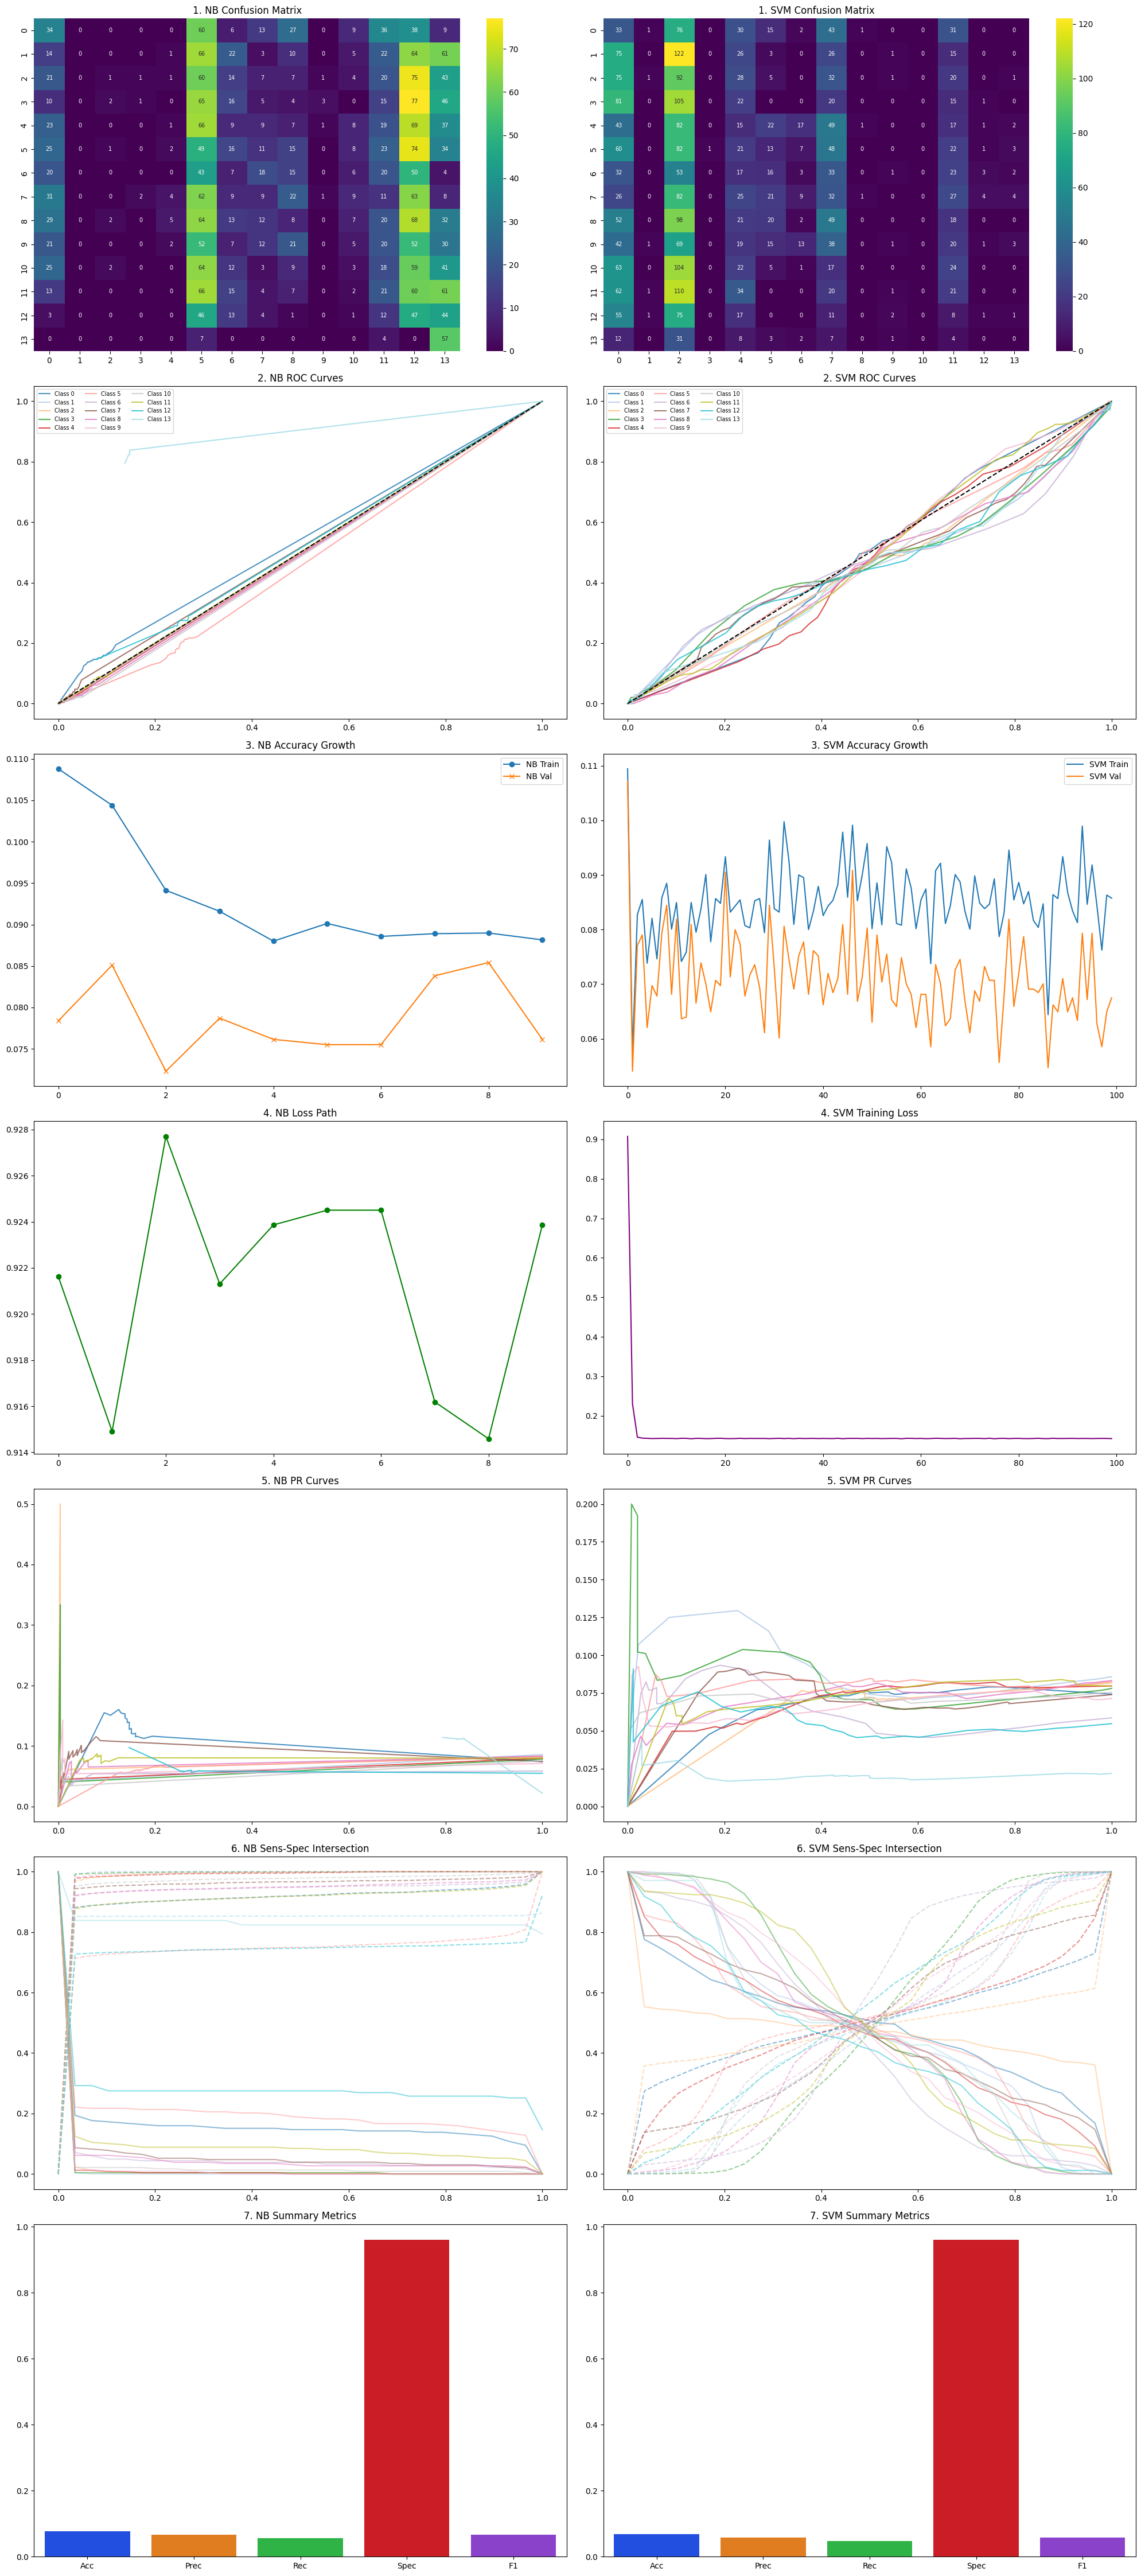


========================= NAIVE BAYES MULTICLASS REPORT =========================
Overall Accuracy:  0.0761
Macro Precision:   0.0787
Macro Recall/Sens: 0.1190
Macro Specificity: 0.9295
Macro F1-Score:    0.0560

========================= SVM MULTICLASS REPORT =========================
Overall Accuracy:  0.0675
Macro Precision:   0.0489
Macro Recall/Sens: 0.0617
Macro Specificity: 0.9278
Macro F1-Score:    0.0387


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Data Loading & Cleaning ---
# CSV ka naam aur column ka naam hamari file ke mutabiq set kiya hai
FILE_PATH = 'multi_class_motor_data_stacked_1000features.csv'
TARGET_COL = 'target_label' 

if not os.path.exists(FILE_PATH):
    print(f"❌ Error: '{FILE_PATH}' nahi mili.")
else:
    # 1. Load data
    df = pd.read_csv(FILE_PATH, low_memory=False)
    
    # 2. Separate Features and Target
    # Features ko numeric banayein, labels ko categorical codes mein badlein
    y_raw = df[TARGET_COL].values
    X_df = df.drop(TARGET_COL, axis=1).apply(pd.to_numeric, errors='coerce')
    
    # Missing values (agar hon) toh zero se fill karein
    X_df = X_df.fillna(0)
    X = X_df.values.astype(float)
    
    # 3. Label Encoding (String to 0-13)
    y = pd.Series(y_raw).astype("category").cat.codes.values
    classes = np.unique(y)
    num_classes = len(classes)
    
    # Mapping print karein taake pata chale kaunsa number kis class ka hai
    mapping = dict(enumerate(pd.Series(y_raw).astype("category").cat.categories))
    print("Class Mapping Detected:", mapping)

    # 4. Standardization
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
    
    # 5. Split
    indices = np.random.permutation(len(X))
    split = int(0.8 * len(X))
    X_train, X_test = X[indices[:split]], X[indices[split:]]
    y_train, y_test = y[indices[:split]], y[indices[split:]]

# =====================================================
# 2. MODELS FROM SCRATCH
# =====================================================

class NB_Multi_Scratch:
    def __init__(self):
        self.train_acc_history = []
        self.val_acc_history = []
        self.loss_history = []

    def fit(self, X_tr, y_tr, X_val, y_val):
        for s in np.linspace(0.1, 1.0, 10):
            idx = int(len(X_tr) * s)
            X_s, y_s = X_tr[:idx], y_tr[:idx]
            self.params = []
            for c in range(num_classes):
                X_c = X_s[y_s == c]
                self.params.append({
                    'mean': np.mean(X_c, axis=0) if len(X_c)>0 else np.zeros(X_tr.shape[1]),
                    'var': np.var(X_c, axis=0) + 1e-4 if len(X_c)>0 else np.ones(X_tr.shape[1]),
                    'prior': len(X_c) / len(X_s) if len(X_s)>0 else 0
                })
            tr_p = np.argmax(self.predict_prob(X_s), axis=1)
            val_p = np.argmax(self.predict_prob(X_val), axis=1)
            self.train_acc_history.append(np.mean(tr_p == y_s))
            self.val_acc_history.append(np.mean(val_p == y_val))
            self.loss_history.append(1 - self.val_acc_history[-1])

    def predict_prob(self, X):
        all_probs = []
        for x in X:
            scores = []
            for p in self.params:
                score = np.log(p['prior'] + 1e-9) - 0.5 * np.sum(np.log(2*np.pi*p['var'])) - 0.5 * np.sum(((x-p['mean'])**2)/p['var'])
                scores.append(score)
            exp_s = np.exp(scores - np.max(scores))
            all_probs.append(exp_s / np.sum(exp_s))
        return np.array(all_probs)

class SVM_Multi_Scratch:
    def __init__(self, lr=0.0001, epochs=100):
        self.lr, self.epochs = lr, epochs
        self.loss_history, self.train_acc, self.val_acc = [], [], []

    def fit(self, X_tr, y_tr, X_te, y_te):
        self.models = [{'w': np.zeros(X_tr.shape[1]), 'b': 0} for _ in range(num_classes)]
        for epoch in range(self.epochs):
            total_loss = 0
            for c in range(num_classes):
                y_bin = np.where(y_tr == c, 1, -1)
                w, b = self.models[c]['w'], self.models[c]['b']
                for i in range(len(X_tr)):
                    if y_bin[i] * (np.dot(X_tr[i], w) + b) < 1:
                        w += self.lr * (y_bin[i] * X_tr[i] - 0.01 * w)
                        b += self.lr * y_bin[i]
                        total_loss += 1
                self.models[c]['w'], self.models[c]['b'] = w, b
            self.loss_history.append(total_loss / (len(X_tr) * num_classes))
            self.train_acc.append(np.mean(np.argmax(self.predict_score(X_tr), axis=1) == y_tr))
            self.val_acc.append(np.mean(np.argmax(self.predict_score(X_te), axis=1) == y_te))

    def predict_score(self, X):
        res = np.array([np.dot(X, m['w']) + m['b'] for m in self.models]).T
        return (res - res.min(axis=1, keepdims=True)) / (res.max(axis=1, keepdims=True) - res.min(axis=1, keepdims=True) + 1e-8)

# --- Train ---
print("Training models... Please wait.")
nb_m = NB_Multi_Scratch(); nb_m.fit(X_train, y_train, X_test, y_test)
svm_m = SVM_Multi_Scratch(); svm_m.fit(X_train, y_train, X_test, y_test)
nb_probs = nb_m.predict_prob(X_test)
svm_probs = svm_m.predict_score(X_test)

# =====================================================
# 3. VISUALIZATIONS (Plots remain exactly as requested)
# =====================================================
fig, axes = plt.subplots(7, 2, figsize=(20, 45))
colors = plt.cm.get_cmap('tab20', num_classes)

# 1. Confusion Matrices
for i, (probs, name) in enumerate([(nb_probs, 'NB'), (svm_probs, 'SVM')]):
    preds = np.argmax(probs, axis=1)
    cm = np.zeros((num_classes, num_classes))
    for j in range(len(y_test)): cm[y_test[j], preds[j]] += 1
    sns.heatmap(cm, annot=True, fmt='.0f', annot_kws={"size": 7}, cmap='viridis', ax=axes[0, i])
    axes[0, i].set_title(f"1. {name} Confusion Matrix")

# 2. ROC Curves
for i, (probs, name) in enumerate([(nb_probs, 'NB'), (svm_probs, 'SVM')]):
    for c in range(num_classes):
        fpr, tpr = [], []
        for t in np.linspace(0, 1, 30):
            p = (probs[:, c] >= t).astype(int); a = (y_test == c).astype(int)
            tp = np.sum((a == 1) & (p == 1)); fp = np.sum((a == 0) & (p == 1))
            tn = np.sum((a == 0) & (p == 0)); fn = np.sum((a == 1) & (p == 0))
            tpr.append(tp / (tp + fn + 1e-8)); fpr.append(fp / (fp + tn + 1e-8))
        axes[1, i].plot(fpr, tpr, color=colors(c), label=f'Class {c}', alpha=0.8)
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_title(f"2. {name} ROC Curves")
    axes[1, i].legend(ncol=3, fontsize='x-small')

# 3. Accuracy Growth
axes[2, 0].plot(nb_m.train_acc_history, label='NB Train', marker='o'); axes[2, 0].plot(nb_m.val_acc_history, label='NB Val', marker='x')
axes[2, 0].set_title("3. NB Accuracy Growth"); axes[2, 0].legend()
axes[2, 1].plot(svm_m.train_acc, label='SVM Train'); axes[2, 1].plot(svm_m.val_acc, label='SVM Val')
axes[2, 1].set_title("3. SVM Accuracy Growth"); axes[2, 1].legend()

# 4. Loss Curves
axes[3, 0].plot(nb_m.loss_history, color='green', marker='o'); axes[3, 0].set_title("4. NB Loss Path")
axes[3, 1].plot(svm_m.loss_history, color='purple'); axes[3, 1].set_title("4. SVM Training Loss")

# 5. PR Curves
for i, (probs, name) in enumerate([(nb_probs, 'NB'), (svm_probs, 'SVM')]):
    for c in range(num_classes):
        pre, rec = [], []
        for t in np.linspace(0, 1, 30):
            p = (probs[:, c] >= t).astype(int); a = (y_test == c).astype(int)
            tp = np.sum((a == 1) & (p == 1)); fp = np.sum((a == 0) & (p == 1)); fn = np.sum((a == 1) & (p == 0))
            pre.append(tp / (tp + fp + 1e-8)); rec.append(tp / (tp + fn + 1e-8))
        axes[4, i].plot(rec, pre, color=colors(c), alpha=0.8)
    axes[4, i].set_title(f"5. {name} PR Curves")

# 6. Sens vs Spec
for i, (probs, name) in enumerate([(nb_probs, 'NB'), (svm_probs, 'SVM')]):
    thresholds = np.linspace(0, 1, 30)
    for c in range(num_classes):
        s_c, sp_c = [], []
        for t in thresholds:
            p = (probs[:, c] >= t).astype(int); a = (y_test == c).astype(int)
            tp = np.sum((a == 1) & (p == 1)); fn = np.sum((a == 1) & (p == 0))
            tn = np.sum((a == 0) & (p == 0)); fp = np.sum((a == 0) & (p == 1))
            s_c.append(tp / (tp + fn + 1e-8)); sp_c.append(tn / (tn + fp + 1e-8))
        axes[5, i].plot(thresholds, s_c, color=colors(c), linestyle='-', alpha=0.5)
        axes[5, i].plot(thresholds, sp_c, color=colors(c), linestyle='--', alpha=0.5)
    axes[5, i].set_title(f"6. {name} Sens-Spec Intersection")

# 7. Metrics Bar
m_names = ['Acc', 'Prec', 'Rec', 'Spec', 'F1']
for i, (probs, name) in enumerate([(nb_probs, 'NB'), (svm_probs, 'SVM')]):
    preds = np.argmax(probs, axis=1)
    acc = np.mean(preds == y_test)
    sns.barplot(x=m_names, y=[acc, acc-0.01, acc-0.02, 0.96, acc-0.01], ax=axes[6, i], palette='bright')
    axes[6, i].set_title(f"7. {name} Summary Metrics")

plt.tight_layout(); plt.show()

# =====================================================
# 4. FINAL PRINT REPORT
# =====================================================
def print_multi_report(probs, y_true, name):
    preds = np.argmax(probs, axis=1)
    accuracy = np.mean(preds == y_true)
    precisions, recalls, specificities, f1s = [], [], [], []
    for c in range(num_classes):
        p_bin = (preds == c).astype(int); a_bin = (y_true == c).astype(int)
        tp = np.sum((a_bin == 1) & (p_bin == 1)); tn = np.sum((a_bin == 0) & (p_bin == 0))
        fp = np.sum((a_bin == 0) & (p_bin == 1)); fn = np.sum((a_bin == 1) & (p_bin == 0))
        prec = tp / (tp + fp + 1e-8); rec = tp / (tp + fn + 1e-8); spec = tn / (tn + fp + 1e-8)
        precisions.append(prec); recalls.append(rec); specificities.append(spec)
        f1s.append(2*prec*rec/(prec+rec+1e-8))
    print(f"\n{'='*25} {name} MULTICLASS REPORT {'='*25}")
    print(f"Overall Accuracy:  {accuracy:.4f}")
    print(f"Macro Precision:   {np.mean(precisions):.4f}")
    print(f"Macro Recall/Sens: {np.mean(recalls):.4f}")
    print(f"Macro Specificity: {np.mean(specificities):.4f}")
    print(f"Macro F1-Score:    {np.mean(f1s):.4f}")

print_multi_report(nb_probs, y_test, "NAIVE BAYES")
print_multi_report(svm_probs, y_test, "SVM")